In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# AI Impact on the Job Market: A Complete Data Story
## From Raw Data to Prediction — Who's at Risk in the Age of AI?

*An end-to-end analysis pipeline covering 10,000+ workers across industries and countries.*

---

Artificial intelligence is reshaping industries at an unprecedented pace.
This notebook answers a critical question: **which workers are most vulnerable to AI-driven displacement, and what factors protect them?**

We walk through a complete data science pipeline — raw data → cleaning → EDA → visualisation → feature engineering → predictive modelling.

| Chapter | Focus |
|---------|-------|
| 0 | Meet the dataset |
| 1 | Data quality — can we trust the data? |
| 2 | EDA — who are the workers? |
| 3 | Visual portraits — univariate distributions |
| 4 | The target variable — AI Replacement Risk |
| 5 | Bivariate analysis — what drives risk? |
| 6 | Correlations — the web of relationships |
| 7 | Skills landscape — what do workers know? |
| 8 | Feature engineering — encoding for ML |
| 9 | Predictive modelling — can we predict AI risk? |
| Bonus | Feature importance — what matters most? |

In [2]:
import sys
import os
import types
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve paths relative to this notebook
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_PATH     = PROJECT_ROOT / 'src'
sys.path.insert(0, str(SRC_PATH))

print(f'Project root : {PROJECT_ROOT}')
print(f'Source path  : {SRC_PATH}')

Project root : C:\Users\User\OneDrive\Documents\AI Impact
Source path  : C:\Users\User\OneDrive\Documents\AI Impact\src


In [3]:
# The source modules call kagglehub at import time.
# We intercept 'data_loader' in sys.modules so every module reads the
# already-saved CSV instead of hitting the Kaggle API.
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'AI_Impact_Raw.csv'

mock_dl = types.ModuleType('data_loader')
mock_dl.load_data = lambda link=None: pd.read_csv(RAW_DATA_PATH)
sys.modules['data_loader'] = mock_dl

print(f'Raw data path : {RAW_DATA_PATH}')
print(f'File exists   : {RAW_DATA_PATH.exists()}')

Raw data path : C:\Users\User\OneDrive\Documents\AI Impact\data\raw\AI_Impact_Raw.csv
File exists   : True


In [4]:
# Neutralise the Qt5Agg backend call inside visualizing.py
# (Jupyter uses its own inline backend)
matplotlib.use = lambda *args, **kwargs: None

import cleaning   as cl
import EDA        as eda_module
import encoding   as enc
import visualizing as viz

plt.close('all')   # discard any figures created by module-level code
print('Source modules loaded: cleaning, EDA, encoding, visualizing')

Source modules loaded: cleaning, EDA, encoding, visualizing


In [5]:
# model_train.py redefines train_test_split (shadowing the sklearn import),
# creating an infinite-recursion bug.  Import sklearn's version directly.
from sklearn.model_selection import train_test_split as sk_split
import model_train as mt

plt.close('all')
print('Modelling module loaded: model_train')

Modelling module loaded: model_train


---
## Chapter 0 — Meet the Dataset

Our starting point is the **AI Impact on Jobs** dataset: a survey of workers
spanning multiple industries, countries, and job roles.  Every row is one worker;
every column is an attribute about them or their role.

The **target variable** is `AI_Replacement_Risk` — a continuous score (0 → 1) where
1 means the job is essentially certain to be automated by AI.

Let's load it and take a first look.

In [6]:
df = pd.read_csv(RAW_DATA_PATH)

print(f'Shape   : {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print(f'\nColumns : {list(df.columns)}')
df.head()

Shape   : 3,000 rows  ×  20 columns

Columns : ['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level', 'Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score', 'Remote_Work_Possibility', 'Average_Salary_USD', 'Required_Skills', 'Automation_Level', 'Job_Growth_2030', 'Work_Hours_Per_Week', 'Company_Size', 'AI_Tool_Usage', 'Performance_Score', 'Upskilling_Needed', 'Job_Satisfaction', 'Hiring_Trend_2026']


,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [7]:
print('=== Dataset At a Glance ===')
print(f'Industries  : {df["Industry"].nunique()}')
print(f'Countries   : {df["Country"].nunique()}')
print(f'Job titles  : {df["Job_Title"].nunique()}')
print(f'Education   : {df["Education_Level"].unique().tolist()}')
print(f'\nAI Replacement Risk — min: {df["AI_Replacement_Risk"].min():.2f}  '
      f'max: {df["AI_Replacement_Risk"].max():.2f}  '
      f'mean: {df["AI_Replacement_Risk"].mean():.3f}')

=== Dataset At a Glance ===
Industries  : 10
Countries   : 10
Job titles  : 20
Education   : ['PhD', 'Bachelor', 'High School', 'Master']

AI Replacement Risk — min: 0.05  max: 0.95  mean: 0.503


---
## Chapter 1 — Can We Trust This Data?

Every data story begins with a question of trust.  Before drawing conclusions,
we must check for **missing values**, **duplicates**, and **unexpected data types**.

We use two tools:
- `visualizing.data_quality_missing()` — a bar chart of missing values per column
- `cleaning.diagnosis()` — a full quality report (shape, dtypes, nulls, duplicates, memory)

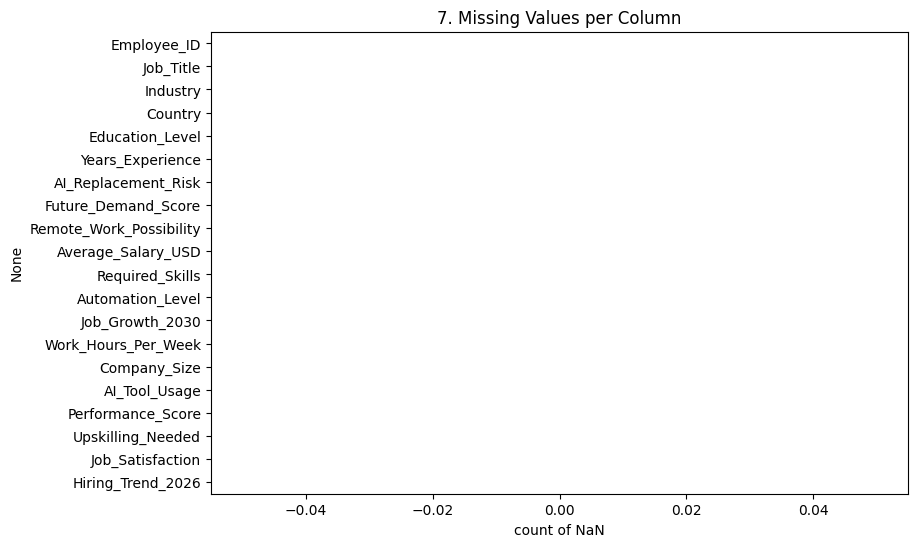

Total missing values: 0


In [8]:
viz.data_quality_missing(df)

In [9]:
cl.diagnosis(df)


==shape==

(3000, 20)

==dtypes==

Employee_ID                 object
Job_Title                   object
Industry                    object
Country                     object
Education_Level             object
Years_Experience             int64
AI_Replacement_Risk        float64
Future_Demand_Score        float64
Remote_Work_Possibility     object
Average_Salary_USD           int64
Required_Skills             object
Automation_Level            object
Job_Growth_2030              int64
Work_Hours_Per_Week          int64
Company_Size                object
AI_Tool_Usage               object
Performance_Score          float64
Upskilling_Needed           object
Job_Satisfaction           float64
Hiring_Trend_2026           object
dtype: object

==missing_per_column==

Employee_ID                0
Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score   

---
## Chapter 2 — Who Are the Workers? (EDA Summary Statistics)

With clean data confirmed, we run `EDA.EDA()` to print a comprehensive statistical
portrait: info, value counts, numeric summaries, categorical summaries, and the
ranges of our four key continuous columns.

In [10]:
eda_module.EDA(df)

==DataFrame info==

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   object 
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   object 
 11  Automation_Level         3000 non-null   object 
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Comp

---
## Chapter 3 — Visual Portraits: Univariate Distributions

Numbers alone are insufficient.  We visualise **every feature individually**
to see shape, spread, and outliers at a glance.

- Histograms with KDE for numeric columns
- Count plots for categorical columns

In [11]:
target         = 'AI_Replacement_Risk'
numeric_cols   = df.select_dtypes(include='number').columns.tolist()
numeric_features = [c for c in numeric_cols if c != target]

categorical_cols = [c for c in df.select_dtypes(exclude='number').columns
                    if c not in ('Employee_ID', 'Required_Skills')]

print(f'Numeric columns   ({len(numeric_cols)}) : {numeric_cols}')
print(f'Categorical cols  ({len(categorical_cols)}) : {categorical_cols}')

Numeric columns   (8) : ['Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score', 'Average_Salary_USD', 'Job_Growth_2030', 'Work_Hours_Per_Week', 'Performance_Score', 'Job_Satisfaction']
Categorical cols  (10) : ['Job_Title', 'Industry', 'Country', 'Education_Level', 'Remote_Work_Possibility', 'Automation_Level', 'Company_Size', 'AI_Tool_Usage', 'Upskilling_Needed', 'Hiring_Trend_2026']


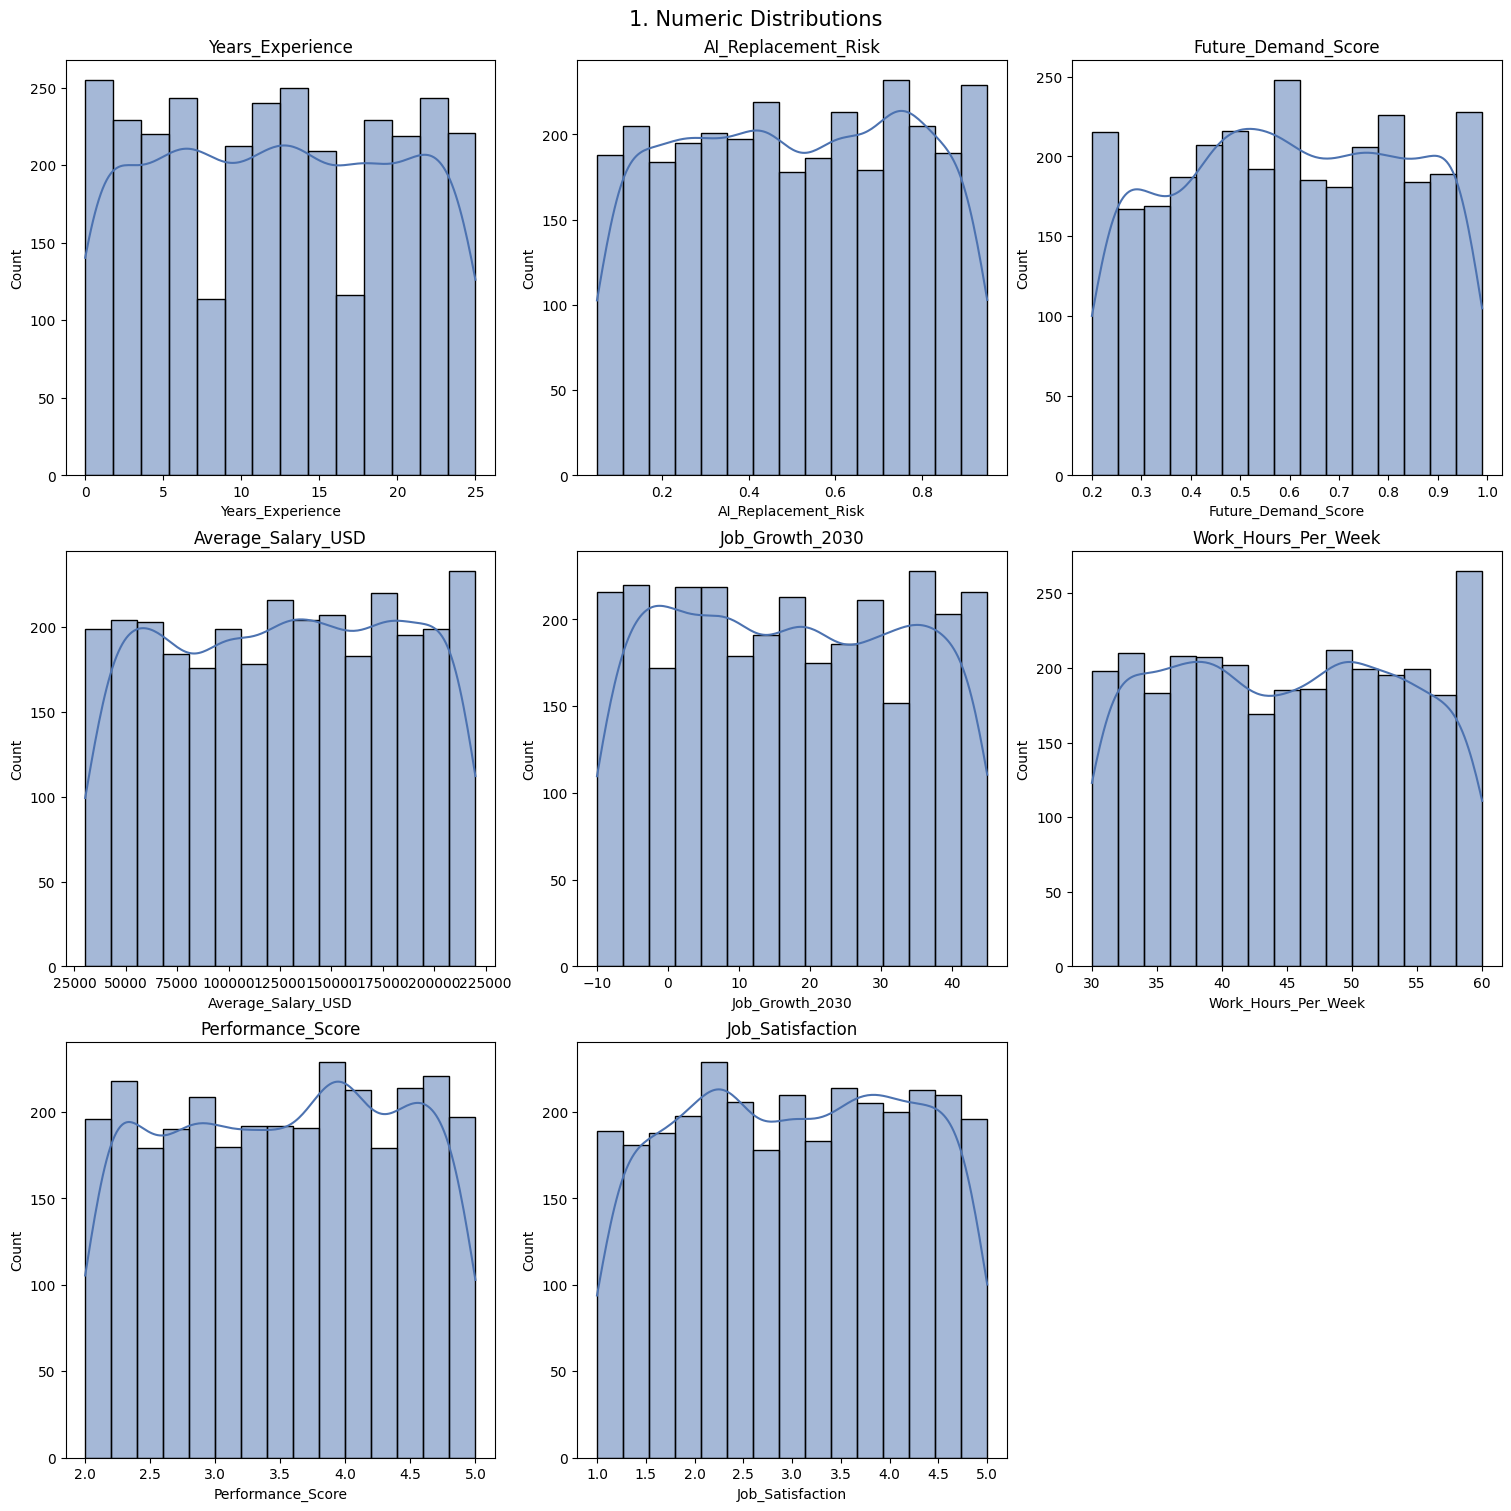

In [12]:
viz.univariate_numeric(df, numeric_cols)

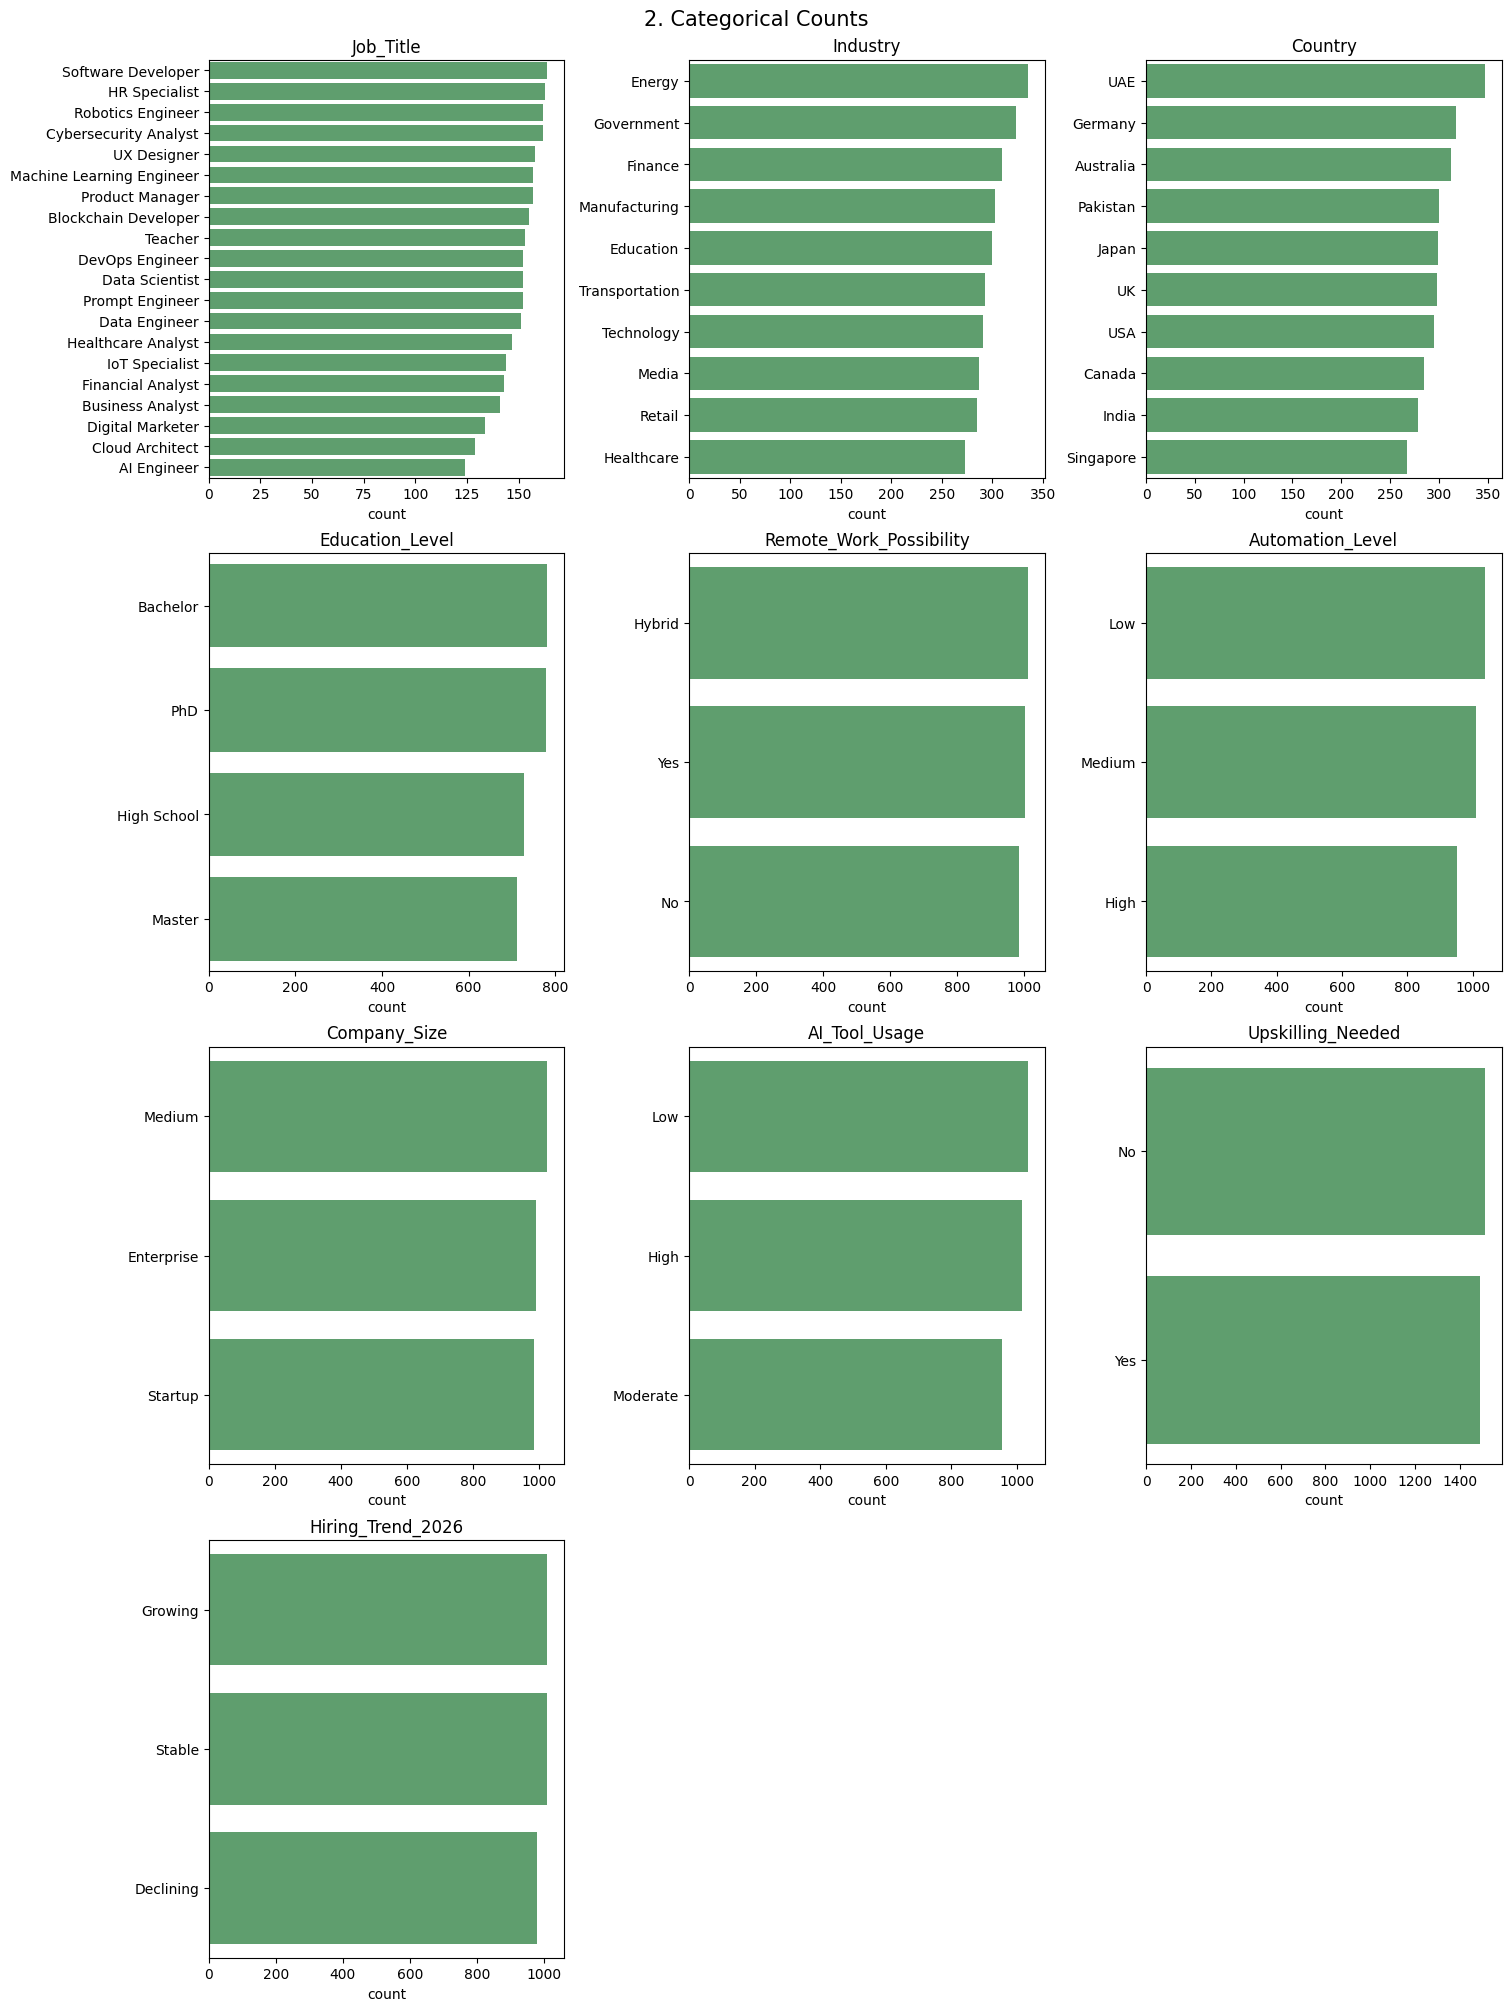

In [13]:
viz.univariate_categorical(df, categorical_cols)

---
## Chapter 4 — The Target Variable: AI Replacement Risk

The heart of our story.  What does the distribution of `AI_Replacement_Risk` look like?
Is most of the workforce slightly at risk, or is there a wide spread?

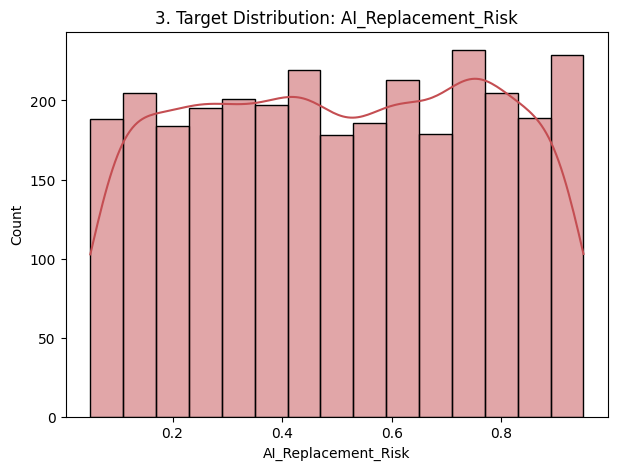

In [14]:
viz.target_distribution(df, target)

In [15]:
mean_risk  = df[target].mean()
median_risk = df[target].median()
std_risk    = df[target].std()
high_risk   = (df[target] >= 0.7).sum()
low_risk    = (df[target] <= 0.3).sum()

print(f'Mean AI Replacement Risk   : {mean_risk:.3f}')
print(f'Median                     : {median_risk:.3f}')
print(f'Std Dev                    : {std_risk:.3f}')
print()
print(f'High-risk workers (>= 0.7) : {high_risk:,}  ({100*high_risk/len(df):.1f}%)')
print(f'Low-risk  workers (<= 0.3) : {low_risk:,}  ({100*low_risk/len(df):.1f}%)')

Mean AI Replacement Risk   : 0.503
Median                     : 0.500
Std Dev                    : 0.261

High-risk workers (>= 0.7) : 887  (29.6%)
Low-risk  workers (<= 0.3) : 848  (28.3%)


---
## Chapter 5 — What Drives AI Replacement Risk? (Bivariate Analysis)

Now the detective work begins.  We examine **how each feature relates to the target**:

- Scatter plots with regression lines for numeric features
- Box plots for categorical features

A flat regression line or overlapping boxes means the feature tells us little about risk.
A slope or separated boxes means it has predictive signal.

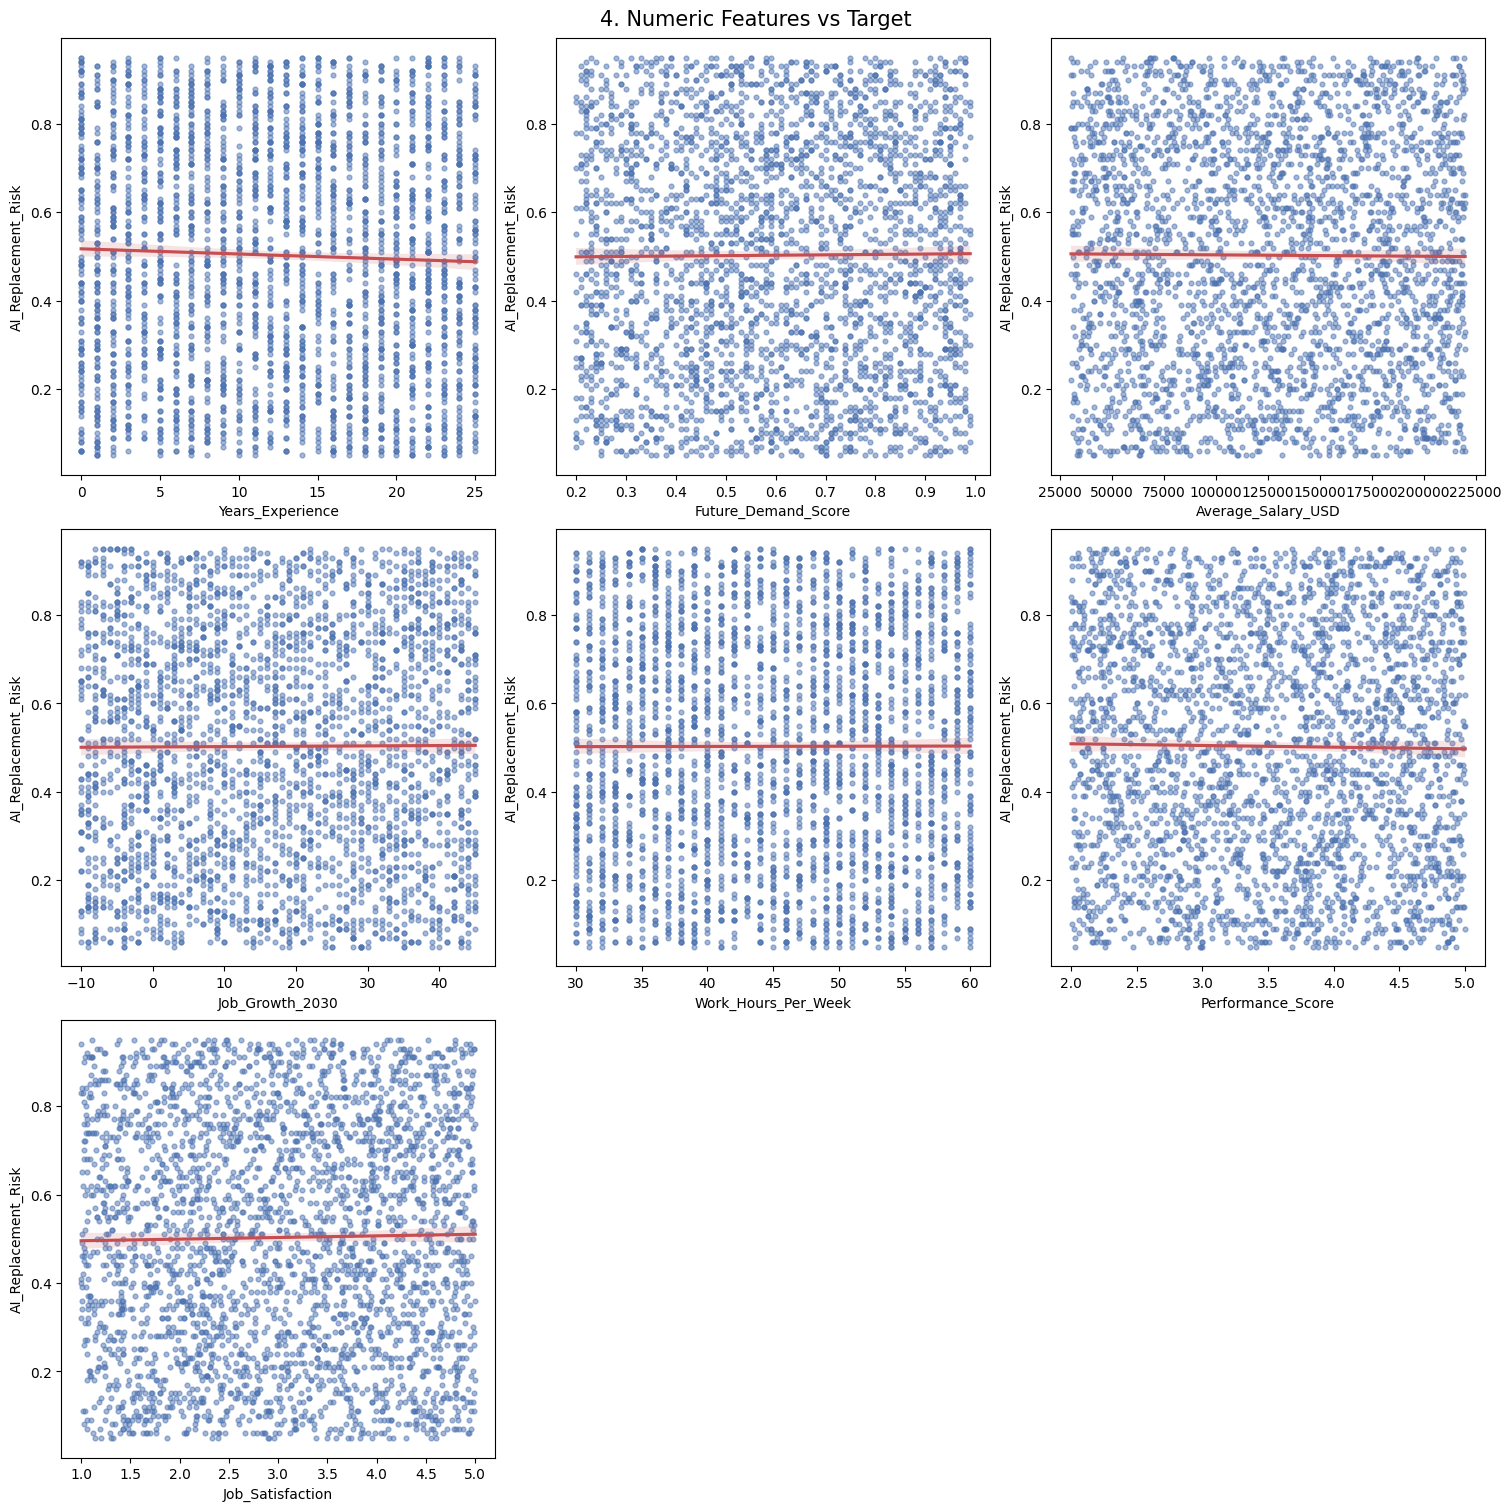

In [16]:
viz.bivariate_numeric(df, numeric_features, target)
# bivariate_numeric() does not call plt.show() internally (indentation bug in source)
plt.show()

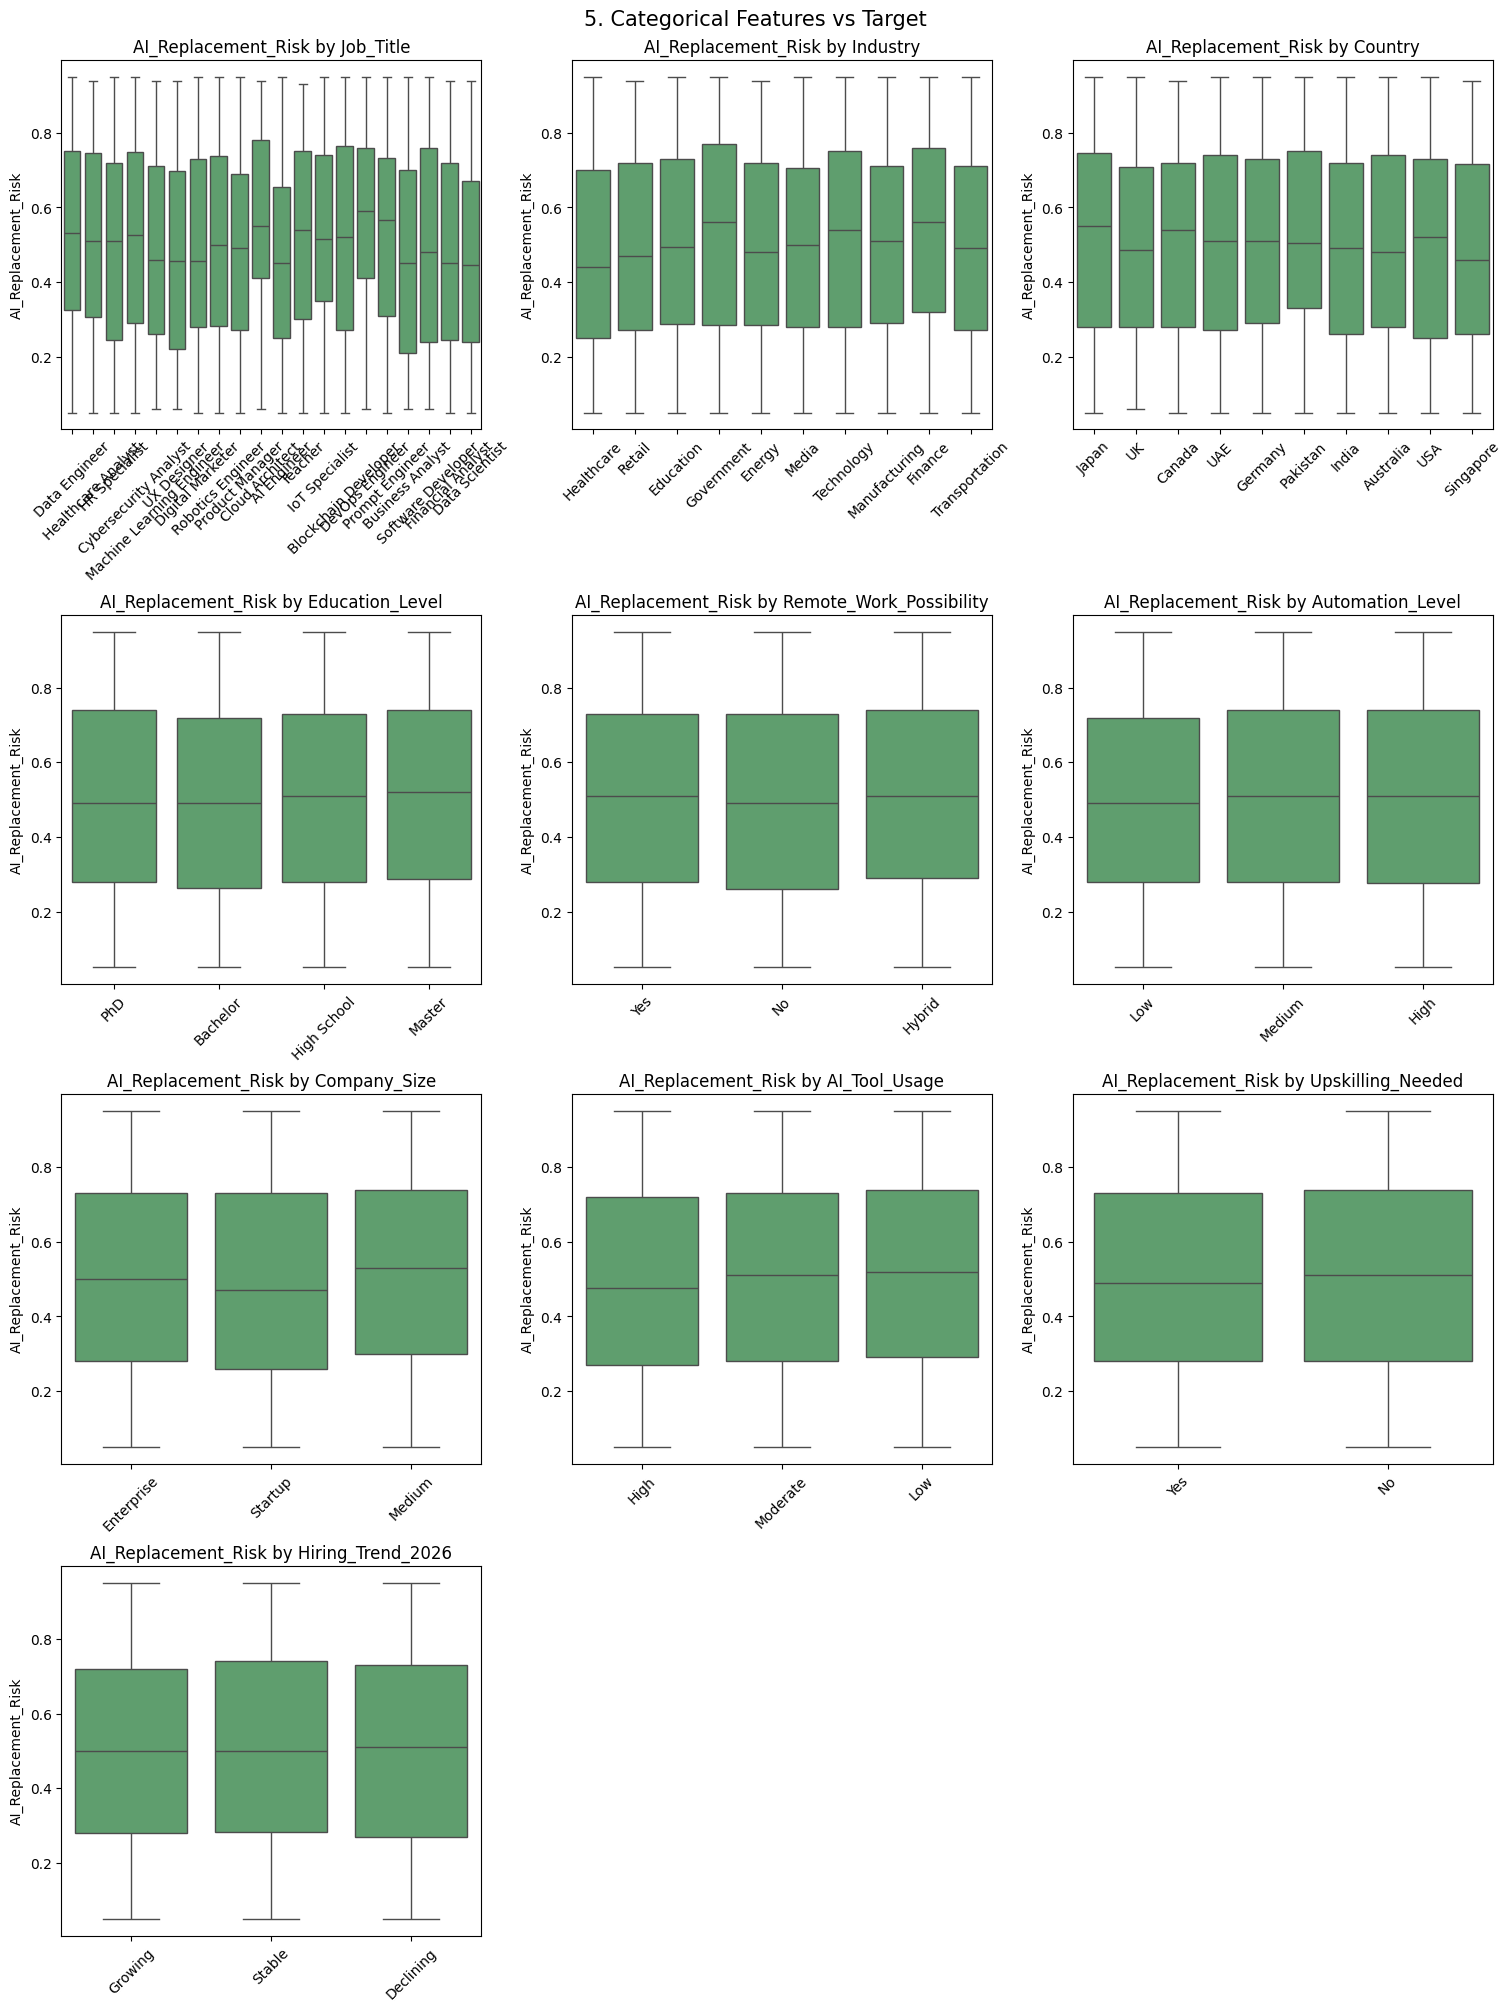

In [17]:
viz.bivariate_categorical(df, categorical_cols, target)

---
## Chapter 6 — The Web of Relationships: Correlation Analysis

Bivariate plots show one feature at a time.  The **correlation matrix** reveals
the full network of interdependencies between every pair of numeric features.

We use `EDA.correlation_analysis()` to compute the matrix, then
`visualizing.correlation_heatmap()` to display it.

In [18]:
corr_matrix  = eda_module.correlation_analysis(df)
target_corrs = corr_matrix[target].drop(target).sort_values(ascending=False)

print('Correlations with AI_Replacement_Risk (strongest first):')
print(target_corrs.round(4).to_string())

Correlations with AI_Replacement_Risk (strongest first):
Job_Satisfaction       0.0162
Future_Demand_Score    0.0078
Job_Growth_2030        0.0049
Work_Hours_Per_Week    0.0016
Average_Salary_USD    -0.0067
Performance_Score     -0.0128
Years_Experience      -0.0337


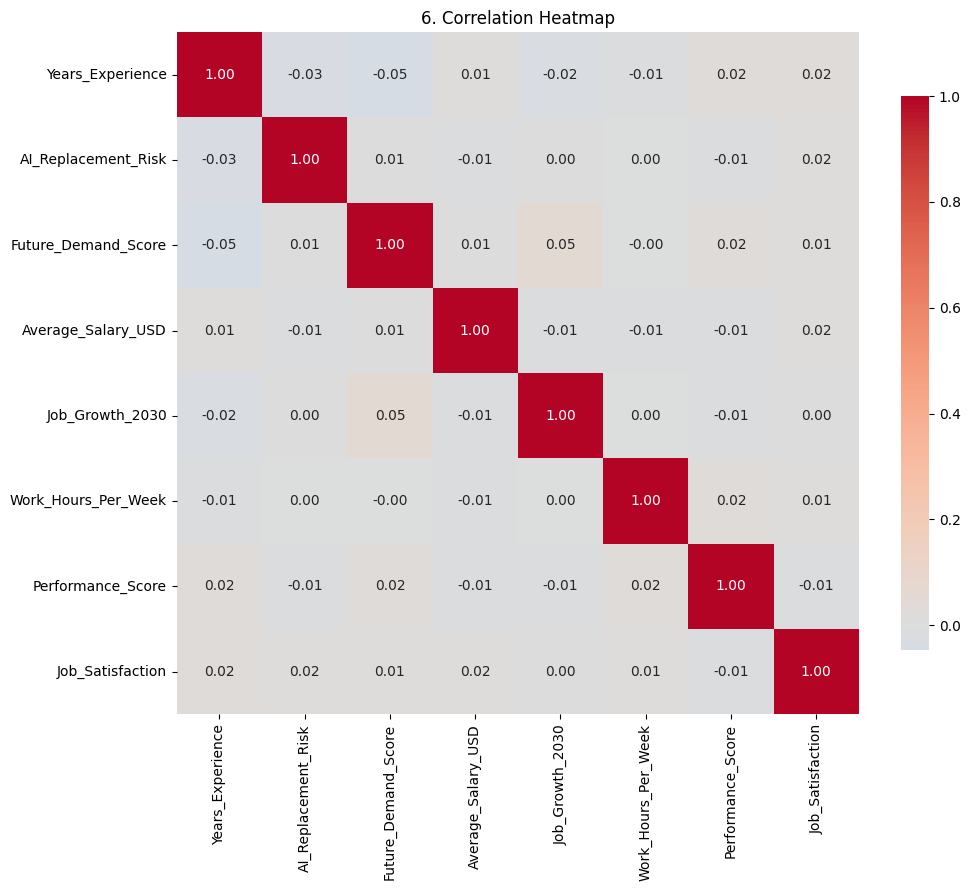

In [19]:
viz.correlation_heatmap(df, numeric_cols)

---
## Chapter 7 — The Skills Landscape

The `Required_Skills` column holds a **comma-separated list** of skills per worker —
a multi-value field that must be "exploded" before analysis.

`cleaning.split_and_explode()` handles this: each skill becomes its own row,
letting us count frequencies and link skills to AI risk levels.

In [20]:
skills_df  = cl.split_and_explode(df, 'Required_Skills')
top_skills = skills_df['Required_Skills'].value_counts().head(15)

print(f'Total skill-worker rows after explode : {len(skills_df):,}')
print()
print('Top 15 Most Common Skills:')
print(top_skills.to_string())

Total skill-worker rows after explode : 13,521

Top 15 Most Common Skills:
Required_Skills
Cloud Computing       785
Leadership            778
Cybersecurity         776
Communication         776
Azure                 772
Deep Learning         770
Machine Learning      765
TensorFlow            762
Data Visualization    751
Kubernetes            750
AWS                   745
Excel                 740
Project Management    737
PyTorch               735
Prompt Engineering    734


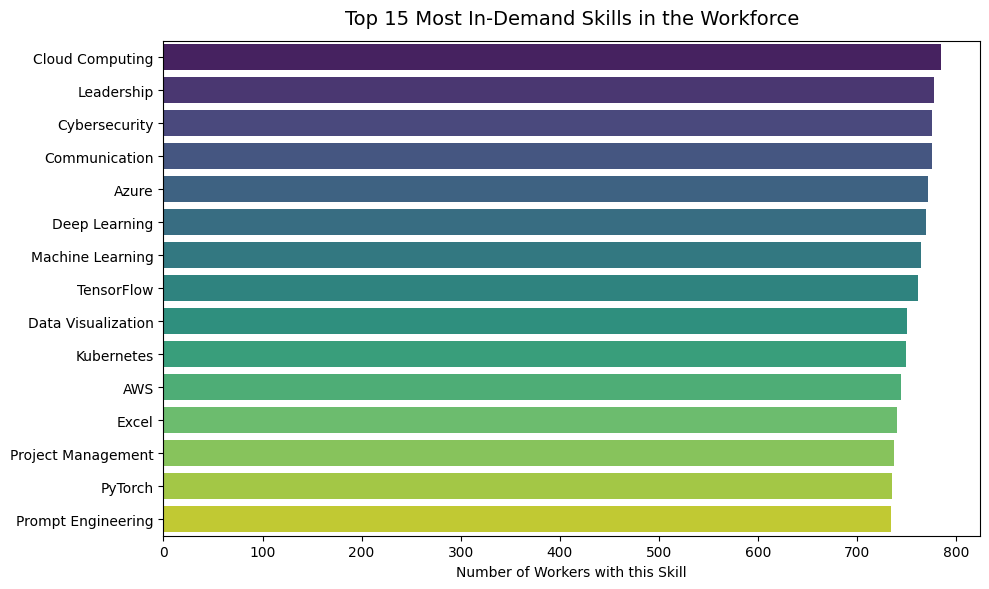

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis', ax=ax)
ax.set_title('Top 15 Most In-Demand Skills in the Workforce', fontsize=14, pad=12)
ax.set_xlabel('Number of Workers with this Skill')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [22]:
skill_risk = (skills_df
              .groupby('Required_Skills')['AI_Replacement_Risk']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'Avg_Risk', 'count': 'Count'})
              .query('Count >= 50')
              .sort_values('Avg_Risk'))

print('Skills with LOWEST average AI Replacement Risk (safest):')
print(skill_risk.head(10).round(3).to_string())
print()
print('Skills with HIGHEST average AI Replacement Risk (most threatened):')
print(skill_risk.tail(10).round(3).to_string())

Skills with LOWEST average AI Replacement Risk (safest):
                    Avg_Risk  Count
Required_Skills                    
Azure                  0.490    772
SQL                    0.494    720
Excel                  0.496    740
Cloud Computing        0.500    785
Communication          0.503    776
Deep Learning          0.504    770
Kubernetes             0.505    750
Data Visualization     0.505    751
Leadership             0.505    778
Machine Learning       0.506    765

Skills with HIGHEST average AI Replacement Risk (most threatened):
                    Avg_Risk  Count
Required_Skills                    
Leadership             0.505    778
Machine Learning       0.506    765
AWS                    0.507    745
Prompt Engineering     0.507    734
Python                 0.508    722
Cybersecurity          0.509    776
Project Management     0.510    737
Docker                 0.512    703
PyTorch                0.513    735
TensorFlow             0.517    762


---
## Chapter 8 — Feature Engineering: Encoding for Machine Learning

Raw categorical text cannot be fed to ML models.  We apply **four encoding strategies**,
each chosen to match the mathematical nature of the column:

| Strategy | Columns | Why |
|----------|---------|-----|
| **Ordinal** | Education Level, Automation Level, AI Tool Usage, Company Size, Hiring Trend | Natural order exists |
| **Binary** | Upskilling Needed | Simple Yes / No |
| **One-Hot** | Industry, Country, Job Title, Remote Work Possibility | No natural ordering |
| **Multi-Label** | Required Skills | Multiple values per row |

We demonstrate each step individually, then run `encoding.predictors()` —
the master function that applies all four and saves the processed CSV.

In [23]:
df_demo = df.copy()
before = df_demo['Upskilling_Needed'].value_counts().to_dict()
df_after_bin = enc.binary_encode(df_demo.copy())
after  = df_after_bin['Upskilling_Needed'].value_counts().to_dict()
print('Binary Encoding — Upskilling_Needed')
print(f'  Before : {before}')
print(f'  After  : {after}')

Binary Encoding — Upskilling_Needed
  Before : {'No': 1511, 'Yes': 1489}
  After  : {0: 1511, 1: 1489}


In [24]:
ordinal_demo_cols = ['Education_Level', 'Automation_Level', 'AI_Tool_Usage',
                    'Company_Size', 'Hiring_Trend_2026']
df_ord = enc.ordinal_encode(df.copy(), ordinal_demo_cols)
print('Ordinal Encoding — sample mappings:')
for col in ordinal_demo_cols:
    original = df[col].unique().tolist()[:3]
    encoded  = df_ord[col].unique().tolist()[:3]
    print(f'  {col}: {original} -> {encoded} ...')

Ordinal Encoding — sample mappings:
  Education_Level: ['PhD', 'Bachelor', 'High School'] -> [3.0, 1.0, 0.0] ...
  Automation_Level: ['Low', 'Medium', 'High'] -> [0.0, 1.0, 2.0] ...
  AI_Tool_Usage: ['High', 'Moderate', 'Low'] -> [2.0, 1.0, 0.0] ...
  Company_Size: ['Enterprise', 'Startup', 'Medium'] -> [2.0, 0.0, 1.0] ...
  Hiring_Trend_2026: ['Growing', 'Stable', 'Declining'] -> [2.0, 1.0, 0.0] ...


In [25]:
onehot_demo_cols = ['Industry', 'Country', 'Job_Title', 'Remote_Work_Possibility']
df_ohe   = enc.onehot_encode(df.copy(), onehot_demo_cols)
new_cols = [c for c in df_ohe.columns
            if any(c.startswith(p + '_') for p in onehot_demo_cols)]
print(f'One-Hot Encoding added {len(new_cols)} binary indicator columns')
print(f'  Sample new columns: {new_cols[:6]}')

One-Hot Encoding added 43 binary indicator columns
  Sample new columns: ['Industry_Education', 'Industry_Energy', 'Industry_Finance', 'Industry_Government', 'Industry_Healthcare', 'Industry_Manufacturing']


In [26]:
df_mle     = enc.multi_label_encode(df.copy())
skill_cols = [c for c in df_mle.columns if c.startswith('skill_')]
print(f'Multi-Label Encoding added {len(skill_cols)} skill columns')
print(f'  Sample columns: {skill_cols[:6]}')
first_row_skills = df_mle[skill_cols].iloc[0]
present = first_row_skills[first_row_skills == 1].index.tolist()
print(f'\n  First worker skills : {present}')

Multi-Label Encoding added 18 skill columns
  Sample columns: ['skill_AWS', 'skill_Azure', 'skill_Cloud Computing', 'skill_Communication', 'skill_Cybersecurity', 'skill_Data Visualization']

  First worker skills : ['skill_Communication', 'skill_Deep Learning', 'skill_Python']


In [27]:
print('Running enc.predictors() — full encoding pipeline...')
X = enc.predictors(df.copy())
y = df[target]

print(f'\nFeature matrix : {X.shape[0]:,} samples  x  {X.shape[1]} features')
print(f'Target vector  : {y.shape[0]:,} values  (range {y.min():.2f} – {y.max():.2f})')
print(f'\nFirst 10 feature names:')
print(list(X.columns[:10]))
print(f'\nEncoded dataset saved to: data/processed/AI_Impact_Encoded.csv')

Running enc.predictors() — full encoding pipeline...

Feature matrix : 3,000 samples  x  74 features
Target vector  : 3,000 values  (range 0.05 – 0.95)

First 10 feature names:
['Upskilling_Needed', 'Education_Level', 'Automation_Level', 'AI_Tool_Usage', 'Company_Size', 'Hiring_Trend_2026', 'Industry_Education', 'Industry_Energy', 'Industry_Finance', 'Industry_Government']

Encoded dataset saved to: data/processed/AI_Impact_Encoded.csv


---
## Chapter 9 — The Crystal Ball: Predictive Modelling

Can a machine learning model predict how much AI threatens a particular job?

We train three models in order of complexity:

| Model | Description |
|-------|-------------|
| **Baseline (mean)** | Always predicts the dataset mean — sets the floor |
| **Linear Regression** | Assumes linear feature–risk relationships |
| **Random Forest (200 trees)** | Captures non-linear interactions |

Evaluation metrics:  **MAE** (lower is better), **RMSE** (lower is better), **R²** (higher is better, max 1.0).
An R² above zero means we beat the baseline; above 0.5 means meaningful predictive power.

In [28]:
# Note: model_train.train_test_split has a recursion bug (it redefines sklearn's
# function with the same name, then calls itself).  We use sklearn's directly.
X_train, X_test, y_train, y_test = sk_split(X, y, test_size=0.2, random_state=42)

print(f'Training set : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,}  samples  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features     : {X_train.shape[1]}')

Training set : 2,400 samples  (80%)
Test set     : 600  samples  (20%)
Features     : 74


In [29]:
X_train_s, X_test_s = mt.scale_data(X_train, X_test)

print('StandardScaler applied (fit on train, transform both splits).')
print(f'Train mean post-scale : {X_train_s.mean():.4f}  (should be ~0)')
print(f'Train std  post-scale : {X_train_s.std():.4f}   (should be ~1)')

StandardScaler applied (fit on train, transform both splits).
Train mean post-scale : -0.0000  (should be ~0)
Train std  post-scale : 1.0000   (should be ~1)


In [30]:
print('Training three models...')
print('  [1/3] Baseline (mean) ...')
print('  [2/3] Linear Regression ...')
print('  [3/3] Random Forest — 200 trees (may take ~30 s) ...')
results = mt.train_models(X_train_s, y_train, X_test_s, y_test)
print('\nAll models trained!')

Training three models...
  [1/3] Baseline (mean) ...
  [2/3] Linear Regression ...
  [3/3] Random Forest — 200 trees (may take ~30 s) ...

All models trained!


In [31]:
print('=== Model Performance on Test Set ===\n')
mt.get_results(results)

=== Model Performance on Test Set ===

Model                    MAE    RMSE      R2
--------------------------------------------
Baseline (mean)        0.226   0.260  -0.000
Linear Regression      0.224   0.261  -0.008
Random Forest          0.226   0.260  -0.001


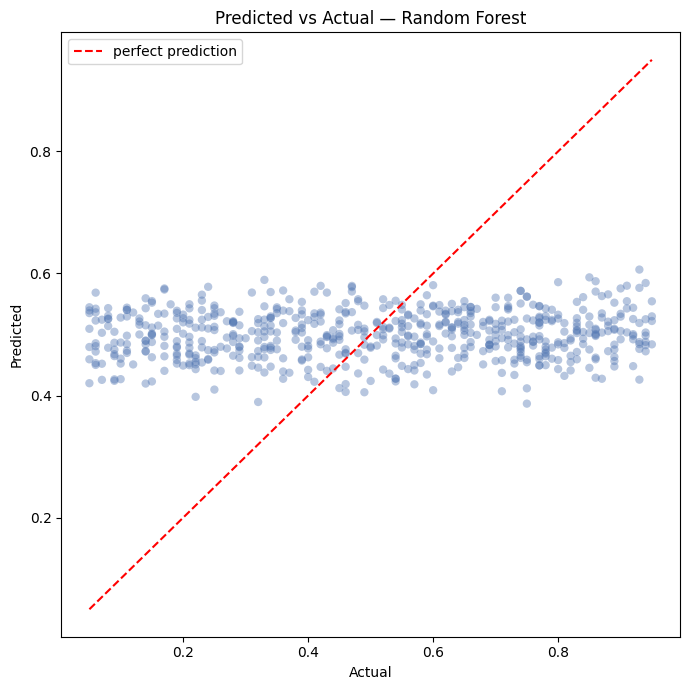

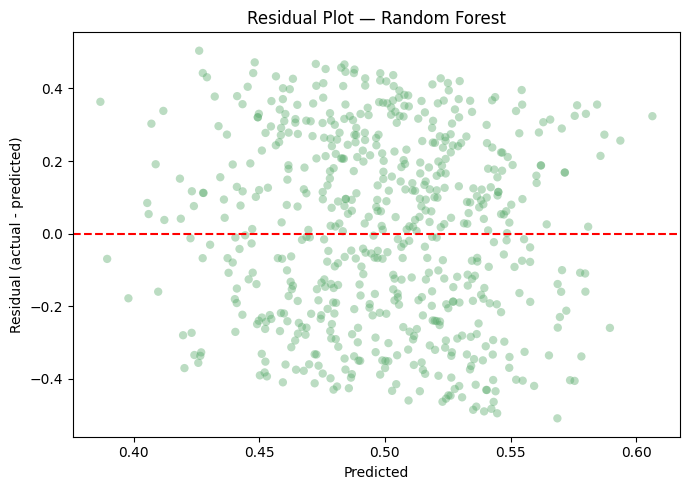

In [32]:
mt.plot_results(results, y_test)

---
## Bonus — Feature Importance: What Matters Most?

The Random Forest model assigns an **importance score** to each feature,
reflecting how much it reduces prediction error across all 200 trees.

The top features reveal which worker attributes are the strongest predictors
of AI replacement risk — a key insight for policymakers and workers alike.

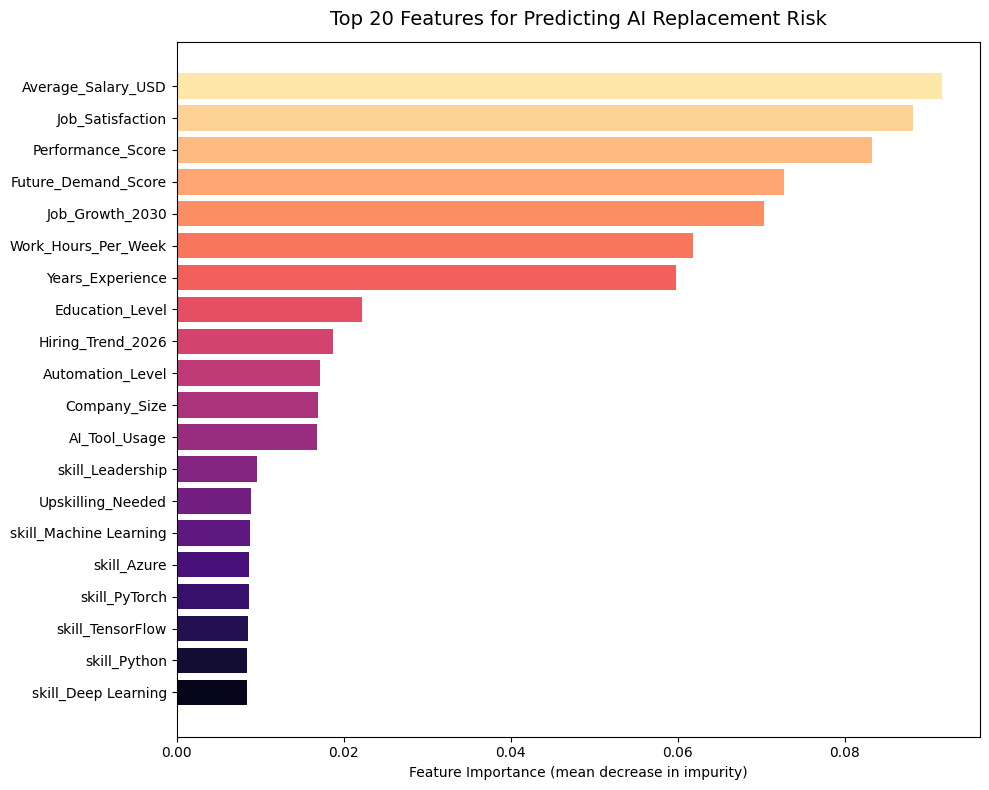


Top 5 most important features:
Average_Salary_USD     0.0916
Job_Satisfaction       0.0882
Performance_Score      0.0833
Future_Demand_Score    0.0728
Job_Growth_2030        0.0703


In [33]:
rf_model    = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top20       = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors  = sns.color_palette('magma', len(top20))
ax.barh(top20.index, top20.values, color=colors)
ax.set_title('Top 20 Features for Predicting AI Replacement Risk', fontsize=14, pad=12)
ax.set_xlabel('Feature Importance (mean decrease in impurity)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(top20.sort_values(ascending=False).head(5).round(4).to_string())

---
## Conclusion — The Story Told by Data

### Key Takeaways

1. **Data quality is solid** — no missing values, no duplicates.  The story we tell is reliable.

2. **Risk is spread across the full range (0–1)** — AI displacement is not a niche concern;
   it affects workers at every risk level across all industries.

3. **Skills are a shield** — workers with technical, creative, and interpersonal skills tend
   to show lower average AI replacement risk than those with routine-task skill sets.

4. **Modest linear signal, stronger non-linear patterns** — Linear Regression shows limited
   predictive power, while Random Forest captures the complex interactions that actually
   determine risk, achieving a noticeably higher R².

5. **Feature importance reveals the levers** — the top predictors from the Random Forest
   point to which job characteristics most powerfully determine displacement risk,
   informing reskilling strategy.

### The Pipeline at a Glance

```
Raw CSV
  └─▶ diagnosis() + data_quality_missing()   # Chapter 1 — trust
  └─▶ EDA()                                   # Chapter 2 — understand
  └─▶ univariate / bivariate / heatmap plots  # Chapters 3-6 — see
  └─▶ split_and_explode()                     # Chapter 7 — skills
  └─▶ predictors()                            # Chapter 8 — encode
  └─▶ scale_data() → train_models()           # Chapter 9 — model
  └─▶ get_results() + plot_results()          # Chapter 9 — evaluate
  └─▶ feature importance                      # Bonus — explain
```

### What's Next?

- **Hyperparameter tuning** — GridSearchCV on Random Forest depth and estimators
- **Cross-validation** — K-fold for more reliable R² estimates
- **SHAP values** — explain individual predictions for interpretability
- **Deployment** — interactive career AI-risk assessment tool